<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-09-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-100.

Características do dataset:

- 60.000 imagens RGB
- 100 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar100

(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode="fine")
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-100 utilizando `tensorflow.keras.datasets.cifar100.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solucao**

O dataset CIFAR-100 possui imagens RGB no formato `(32, 32, 3)`. Apos o flatten, cada imagem passa a ter `32 * 32 * 3 = 3072` features. O flatten e necessario porque uma MLP recebe uma matriz tabular 2D, com uma amostra por linha e as features nas colunas. A normalizacao transforma os pixels de `0-255` para `0-1`, reduzindo a escala das entradas e ajudando o otimizador a convergir com mais estabilidade.

In [1]:
import sys
import time
import tarfile
import pickle
import urllib.request
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=ConvergenceWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from utils import set_seed

SEED = 42
VALIDATION_SIZE = 0.2
# Use None para treinar com as 50.000 imagens de treino. O subconjunto deixa as comparacoes viaveis localmente.
SUBSET_SIZE = 10_000

set_seed(SEED)

CIFAR100_URL = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
CIFAR100_ARCHIVE = PROJECT_ROOT / "data" / "raw" / "cifar-100-python.tar.gz"
CIFAR100_DIR = PROJECT_ROOT / "data" / "raw" / "cifar-100-python"


def safe_extract_tar(tar, destination):
    destination = destination.resolve()
    for member in tar.getmembers():
        target_path = (destination / member.name).resolve()
        if destination != target_path and destination not in target_path.parents:
            raise RuntimeError(f"Caminho inseguro no arquivo tar: {member.name}")
    tar.extractall(destination)


def load_cifar100_from_archive():
    CIFAR100_ARCHIVE.parent.mkdir(parents=True, exist_ok=True)

    if not CIFAR100_ARCHIVE.exists():
        print("Baixando CIFAR-100 do site oficial...")
        urllib.request.urlretrieve(CIFAR100_URL, CIFAR100_ARCHIVE)

    train_file = CIFAR100_DIR / "train"
    if not train_file.exists():
        with tarfile.open(CIFAR100_ARCHIVE, "r:gz") as tar:
            safe_extract_tar(tar, CIFAR100_ARCHIVE.parent)

    with train_file.open("rb") as file:
        train_data = pickle.load(file, encoding="latin1")

    X_train_full = train_data["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train_full = np.array(train_data["fine_labels"]).reshape(-1, 1)
    return X_train_full, y_train_full


def load_cifar100_raw():
    try:
        from tensorflow.keras.datasets import cifar100

        (X_train_full, y_train_full), _ = cifar100.load_data(label_mode="fine")
        return X_train_full, y_train_full
    except Exception as error:
        print(
            "TensorFlow/Keras nao esta disponivel corretamente "
            f"({type(error).__name__}: {error}). Usando fallback direto do CIFAR-100."
        )
        return load_cifar100_from_archive()


def load_data(seed=42, validation_size=0.2, subset_size=None):
    X_train_full, y_train_full = load_cifar100_raw()
    y_train_full = y_train_full.ravel()
    original_shape = X_train_full.shape[1:]

    X_flat = X_train_full.reshape(X_train_full.shape[0], -1).astype("float32") / 255.0

    if subset_size is not None:
        n_classes = len(np.unique(y_train_full))
        min_subset_size = int(np.ceil(n_classes / min(validation_size, 1 - validation_size)))
        if subset_size < min_subset_size:
            raise ValueError(f"subset_size deve ser pelo menos {min_subset_size} para split estratificado.")

        X_flat, _, y_train_full, _ = train_test_split(
            X_flat,
            y_train_full,
            train_size=subset_size,
            random_state=seed,
            stratify=y_train_full,
        )

    X_train, X_val, y_train, y_val = train_test_split(
        X_flat,
        y_train_full,
        test_size=validation_size,
        random_state=seed,
        stratify=y_train_full,
    )

    print(f"Formato original das imagens: {original_shape}")
    print(f"Features apos flatten: {X_flat.shape[1]}")
    print(f"Treino: {X_train.shape} | Validacao: {X_val.shape}")

    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = load_data(
    seed=SEED,
    validation_size=VALIDATION_SIZE,
    subset_size=SUBSET_SIZE,
)

TensorFlow/Keras nao esta disponivel corretamente (ModuleNotFoundError: No module named 'tensorflow.python'). Usando fallback direto do CIFAR-100.
Formato original das imagens: (32, 32, 3)
Features apos flatten: 3072
Treino: (8000, 3072) | Validacao: (2000, 3072)


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solucao**

Para uma primeira camada com `h` neuronios, a quantidade de parametros e `(3072 * h) + h`: um peso para cada feature de entrada ligado a cada neuronio, mais um bias por neuronio. Por exemplo, com arquitetura `(64,)`, a primeira camada possui `3072 * 64 + 64 = 196672` parametros. A ReLU aplica `max(0, x)`, preservando valores positivos e zerando valores negativos, o que ajuda a reduzir saturacao e acelerar o treinamento. MLPs tem muitos parametros em imagens porque, apos o flatten, cada neuronio fica conectado a todos os pixels, sem compartilhamento espacial como acontece em CNNs.

In [2]:
def count_first_layer_params(n_features, first_hidden_units):
    return (n_features * first_hidden_units) + first_hidden_units


def count_mlp_params(n_features, hidden_layers, n_outputs):
    layer_sizes = [n_features, *hidden_layers, n_outputs]
    return int(
        sum(
            (layer_sizes[i] * layer_sizes[i + 1]) + layer_sizes[i + 1]
            for i in range(len(layer_sizes) - 1)
        )
    )


def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=20,
    batch_size=256,
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        learning_rate="constant",
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size,
        solver="adam",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        verbose=False,
    )
    model.fit(X_train, y_train)
    return model


example_hidden_layers = (64,)
first_layer_params = count_first_layer_params(X_train.shape[1], example_hidden_layers[0])
total_params = count_mlp_params(
    X_train.shape[1],
    example_hidden_layers,
    len(np.unique(y_train)),
)

print(f"Parametros na primeira camada {example_hidden_layers}: {first_layer_params}")
print(f"Parametros totais estimados da MLP {example_hidden_layers}: {total_params}")

Parametros na primeira camada (64,): 196672
Parametros totais estimados da MLP (64,): 203172


# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solucao**

A accuracy representa a proporcao de exemplos classificados corretamente. Precision mede, entre as amostras previstas como uma classe, quantas realmente pertenciam a ela; recall mede, entre as amostras reais de uma classe, quantas foram encontradas pelo modelo. O f1-score e importante quando queremos equilibrar precision e recall, especialmente em bases com classes dificeis, erros assimetricos ou distribuicao desbalanceada.

In [3]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }


baseline_model = train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=SEED,
    max_iter=20,
    batch_size=256,
)

baseline_metrics = evaluate(baseline_model, X_val, y_val)
baseline_metrics_df = pd.DataFrame([baseline_metrics])
display(baseline_metrics_df)

,accuracy,precision,recall,f1_score
0,0.059,0.044158,0.059,0.033811


A interpretacao deve considerar que o CIFAR-100 e dificil para uma MLP simples: sao 100 classes, imagens pequenas e muita variacao visual. Assim, resultados modestos sao esperados. Uma accuracy baixa indica que o flatten descarta a estrutura espacial da imagem; precision, recall e f1-score ajudam a observar se o modelo erra de forma concentrada em algumas classes ou de maneira mais distribuida.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solucao**

O codigo abaixo cria uma funcao unica de experimento para registrar parametros, metricas e tempo de treinamento no MLflow. Depois das execucoes, a melhor configuracao pode ser identificada ordenando a tabela por `accuracy` e `f1_score`. O rastreamento experimental e util porque preserva historico, hiperparametros, metricas e comparacoes, evitando decisoes baseadas apenas em memoria ou em execucoes isoladas.

In [4]:
mlflow.set_tracking_uri((PROJECT_ROOT / "mlruns").as_uri())
mlflow.set_experiment("cifar100_mlp")

EXPERIMENT_RESULTS = []


def trained_parameter_count(model):
    return int(sum(w.size + b.size for w, b in zip(model.coefs_, model.intercepts_)))


def results_to_frame(results):
    rows = []
    for result in results:
        rows.append({key: value for key, value in result.items() if key != "loss_curve"})
    return pd.DataFrame(rows)


def plot_loss_curves(results, title):
    plt.figure(figsize=(9, 5))
    for result in results:
        plt.plot(result["loss_curve"], label=result["run_name"])
    plt.title(title)
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def run_experiment(
    run_name,
    activation,
    hidden_layers,
    learning_rate,
    max_iter=20,
    batch_size=256,
    seed=SEED,
):
    params = {
        "activation": activation,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
        "seed": seed,
        "subset_size": SUBSET_SIZE,
    }

    with mlflow.start_run(run_name=run_name):
        for key, value in params.items():
            mlflow.log_param(key, value)

        start = time.perf_counter()
        model = train_mlp(
            X_train,
            y_train,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size,
        )
        training_time = time.perf_counter() - start

        metrics = evaluate(model, X_val, y_val)
        train_accuracy = accuracy_score(y_train, model.predict(X_train))
        generalization_gap = train_accuracy - metrics["accuracy"]

        extra_metrics = {
            "training_time": training_time,
            "train_accuracy": train_accuracy,
            "generalization_gap": generalization_gap,
            "n_iter": model.n_iter_,
            "final_loss": model.loss_,
            "n_parameters": trained_parameter_count(model),
        }

        for key, value in {**metrics, **extra_metrics}.items():
            mlflow.log_metric(key, float(value))

    result = {
        "run_name": run_name,
        "activation": activation,
        "hidden_layers": hidden_layers,
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
        **metrics,
        **extra_metrics,
        "loss_curve": model.loss_curve_,
    }
    EXPERIMENT_RESULTS.append(result)
    return model, result


tracked_baseline_model, tracked_baseline_result = run_experiment(
    run_name="baseline_relu_64_lr_001",
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    max_iter=20,
    batch_size=256,
)

display(results_to_frame([tracked_baseline_result]))
print(f"MLflow local: {PROJECT_ROOT / 'mlruns'}")
print("Para abrir a interface: mlflow ui --backend-store-uri mlruns")

C:\Users\davir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2026/05/26 21:30:42 INFO mlflow.tracking.fluent: Experiment with name 'cifar100_mlp' does not exist. Creating a new experiment.


,run_name,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,n_iter,final_loss,n_parameters
0,baseline_relu_64_lr_001,relu,"(64,)",0.001,20,256,0.059,0.044158,0.059,0.033811,2.966452,0.07075,0.01175,20,4.063727,203172


MLflow local: c:\Users\davir\Desktop\atividade-05-deep-learning-ii-daviruy61\mlruns
Para abrir a interface: mlflow ui --backend-store-uri mlruns


# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solucao**

A comparacao mantem arquitetura, learning rate e seed iguais, variando apenas a funcao de ativacao. A tabela `activation_results_df` mostra a melhor ativacao pelos valores observados. Em geral, a ReLU tende a convergir melhor em redes profundas porque reduz saturacao e facilita o fluxo de gradientes; `logistic` e `tanh` podem apresentar treinamento mais lento por saturarem em regioes extremas.

,run_name,activation,accuracy,precision,recall,f1_score,n_iter,final_loss,training_time,generalization_gap
0,activation_logistic_layers_64_lr_001,logistic,0.1105,0.075194,0.1105,0.079036,20,3.756690,3.660141,0.037375
1,activation_tanh_layers_64_lr_001,tanh,0.1030,0.083081,0.1030,0.079951,20,3.642414,3.045265,0.058000
2,activation_relu_layers_64_lr_001,relu,0.0590,0.044158,0.0590,0.033811,20,4.063727,2.956968,0.011750


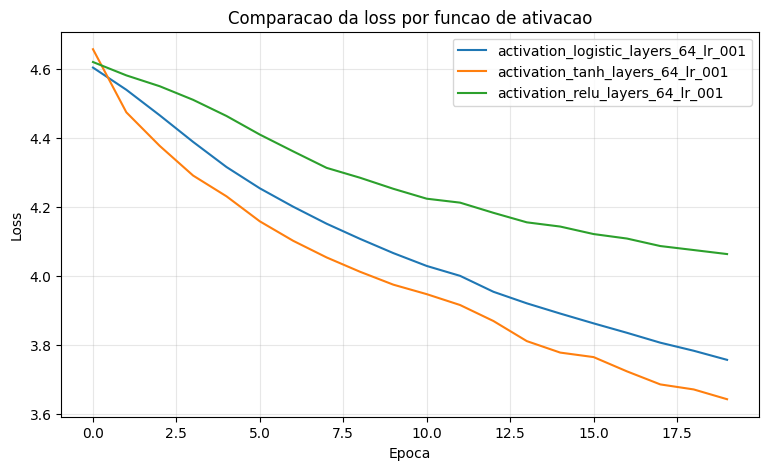

In [5]:
activation_results = []
activation_models = {}

for activation in ["logistic", "tanh", "relu"]:
    model, result = run_experiment(
        run_name=f"activation_{activation}_layers_64_lr_001",
        activation=activation,
        hidden_layers=(64,),
        learning_rate=0.001,
        max_iter=20,
        batch_size=256,
    )
    activation_models[activation] = model
    activation_results.append(result)

activation_results_df = results_to_frame(activation_results).sort_values(
    ["accuracy", "f1_score"],
    ascending=False,
)

display(
    activation_results_df[
        [
            "run_name",
            "activation",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "n_iter",
            "final_loss",
            "training_time",
            "generalization_gap",
        ]
    ]
)

plot_loss_curves(activation_results, "Comparacao da loss por funcao de ativacao")

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solucao**

A comparacao abaixo varia apenas a arquitetura, mantendo ativacao, learning rate e seed constantes. Redes maiores aumentam o custo computacional e a quantidade de parametros, mas nao garantem melhor validacao. O melhor tradeoff deve equilibrar `accuracy`/`f1_score`, tempo de treinamento e `generalization_gap`; um gap alto entre treino e validacao e sinal de overfitting.

,run_name,hidden_layers,n_parameters,accuracy,f1_score,train_accuracy,generalization_gap,training_time,n_iter,final_loss
3,architecture_256x128_relu_lr_001,"(256, 128)",832484,0.1425,0.122419,0.195875,0.053375,8.232176,20,3.328090
2,architecture_128x64_relu_lr_001,"(128, 64)",408100,0.1095,0.087090,0.139875,0.030375,5.301987,20,3.558797
1,architecture_64_relu_lr_001,"(64,)",203172,0.0590,0.033811,0.070750,0.011750,3.298744,20,4.063727
0,architecture_32_relu_lr_001,"(32,)",101636,0.0240,0.004596,0.026500,0.002500,1.757953,15,4.310766


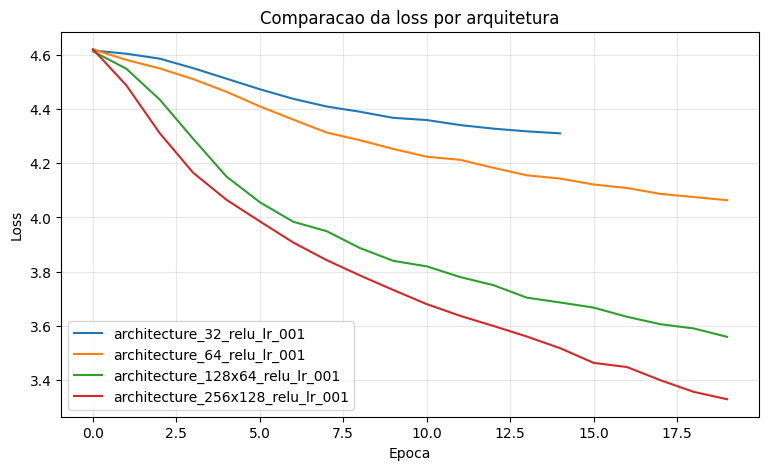

In [6]:
architecture_results = []
architecture_models = {}

for hidden_layers in [(32,), (64,), (128, 64), (256, 128)]:
    label = "x".join(str(layer) for layer in hidden_layers)
    model, result = run_experiment(
        run_name=f"architecture_{label}_relu_lr_001",
        activation="relu",
        hidden_layers=hidden_layers,
        learning_rate=0.001,
        max_iter=20,
        batch_size=256,
    )
    architecture_models[hidden_layers] = model
    architecture_results.append(result)

architecture_results_df = results_to_frame(architecture_results).sort_values(
    ["accuracy", "f1_score"],
    ascending=False,
)

display(
    architecture_results_df[
        [
            "run_name",
            "hidden_layers",
            "n_parameters",
            "accuracy",
            "f1_score",
            "train_accuracy",
            "generalization_gap",
            "training_time",
            "n_iter",
            "final_loss",
        ]
    ]
)

plot_loss_curves(architecture_results, "Comparacao da loss por arquitetura")

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

,run_name,learning_rate,accuracy,f1_score,train_accuracy,generalization_gap,n_iter,final_loss,training_time
2,learning_rate_0_001_relu_layers_64,0.001,0.059,0.033811,0.07075,0.01175,20,4.063727,2.944541
0,learning_rate_0_1_relu_layers_64,0.100,0.010,0.000198,0.01000,0.00000,9,4.633167,1.335580
1,learning_rate_0_01_relu_layers_64,0.010,0.010,0.000198,0.01000,0.00000,10,4.606652,1.551853


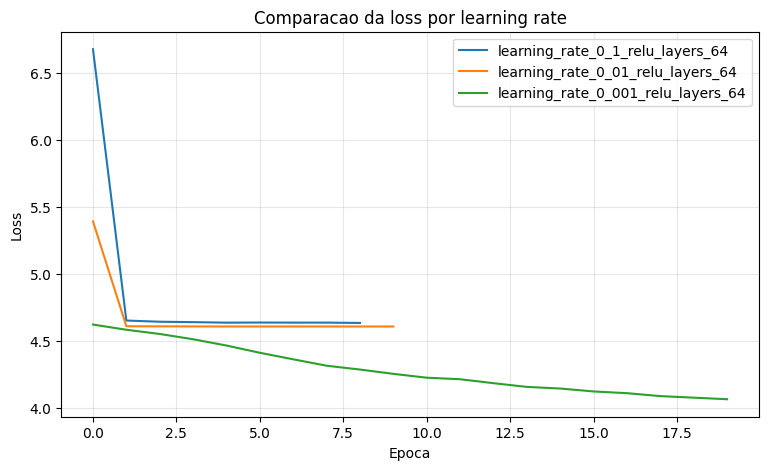

In [7]:
learning_rate_results = []
learning_rate_models = {}

for learning_rate in [0.1, 0.01, 0.001]:
    label = str(learning_rate).replace(".", "_")
    model, result = run_experiment(
        run_name=f"learning_rate_{label}_relu_layers_64",
        activation="relu",
        hidden_layers=(64,),
        learning_rate=learning_rate,
        max_iter=20,
        batch_size=256,
    )
    learning_rate_models[learning_rate] = model
    learning_rate_results.append(result)

learning_rate_results_df = results_to_frame(learning_rate_results).sort_values(
    ["accuracy", "f1_score"],
    ascending=False,
)

display(
    learning_rate_results_df[
        [
            "run_name",
            "learning_rate",
            "accuracy",
            "f1_score",
            "train_accuracy",
            "generalization_gap",
            "n_iter",
            "final_loss",
            "training_time",
        ]
    ]
)

plot_loss_curves(learning_rate_results, "Comparacao da loss por learning rate")

**Solucao**

A melhor taxa de aprendizado e a primeira linha de `learning_rate_results_df` apos ordenar por `accuracy` e `f1_score`. Em geral, `0.1` tende a ser instavel porque os passos do gradiente ficam grandes e podem fazer a loss oscilar ou piorar. Taxas muito baixas, como `0.001`, costumam ser mais estaveis, mas podem exigir mais epocas para convergir. A taxa intermediaria `0.01` pode ser um bom compromisso, mas a decisao final deve vir da tabela e da curva de loss.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

In [8]:
all_results_df = results_to_frame(EXPERIMENT_RESULTS).sort_values(
    ["accuracy", "f1_score"],
    ascending=False,
)

best_result = all_results_df.iloc[0]

display(
    all_results_df[
        [
            "run_name",
            "activation",
            "hidden_layers",
            "learning_rate",
            "accuracy",
            "f1_score",
            "train_accuracy",
            "generalization_gap",
            "training_time",
            "n_parameters",
            "final_loss",
        ]
    ]
)

display(best_result.to_frame(name="melhor_configuracao"))

,run_name,activation,hidden_layers,learning_rate,accuracy,f1_score,train_accuracy,generalization_gap,training_time,n_parameters,final_loss
7,architecture_256x128_relu_lr_001,relu,"(256, 128)",0.001,0.1425,0.122419,0.195875,0.053375,8.232176,832484,3.328090
1,activation_logistic_layers_64_lr_001,logistic,"(64,)",0.001,0.1105,0.079036,0.147875,0.037375,3.660141,203172,3.756690
6,architecture_128x64_relu_lr_001,relu,"(128, 64)",0.001,0.1095,0.087090,0.139875,0.030375,5.301987,408100,3.558797
2,activation_tanh_layers_64_lr_001,tanh,"(64,)",0.001,0.1030,0.079951,0.161000,0.058000,3.045265,203172,3.642414
0,baseline_relu_64_lr_001,relu,"(64,)",0.001,0.0590,0.033811,0.070750,0.011750,2.966452,203172,4.063727
3,activation_relu_layers_64_lr_001,relu,"(64,)",0.001,0.0590,0.033811,0.070750,0.011750,2.956968,203172,4.063727
5,architecture_64_relu_lr_001,relu,"(64,)",0.001,0.0590,0.033811,0.070750,0.011750,3.298744,203172,4.063727
10,learning_rate_0_001_relu_layers_64,relu,"(64,)",0.001,0.0590,0.033811,0.070750,0.011750,2.944541,203172,4.063727
4,architecture_32_relu_lr_001,relu,"(32,)",0.001,0.0240,0.004596,0.026500,0.002500,1.757953,101636,4.310766
8,learning_rate_0_1_relu_layers_64,relu,"(64,)",0.100,0.0100,0.000198,0.010000,0.000000,1.335580,203172,4.633167


,melhor_configuracao
run_name,architecture_256x128_relu_lr_001
activation,relu
hidden_layers,"(256, 128)"
learning_rate,0.001
max_iter,20
batch_size,256
accuracy,0.1425
precision,0.138802
recall,0.1425
f1_score,0.122419


**Discussao final**

A loss mostra se o treinamento esta aprendendo de forma progressiva: curvas suaves e descendentes indicam otimizacao mais estavel, enquanto oscilacoes ou valores que nao caem sugerem learning rate alto, arquitetura inadequada ou dificuldade do modelo. O learning rate controla o tamanho do passo no ajuste dos pesos; quando e alto demais, o treinamento pode ficar instavel, e quando e baixo demais, a convergencia fica lenta.

A arquitetura influencia capacidade e custo. Camadas maiores aumentam o numero de parametros e podem melhorar a representacao, mas tambem elevam tempo de treinamento e risco de overfitting. Por isso, a melhor configuracao final e a indicada por `best_result`, combinando validacao, f1-score, gap de generalizacao e custo computacional. A maior dificuldade observada e que uma MLP trata a imagem como vetor, perdendo relacoes locais entre pixels, bordas e texturas. Isso limita o desempenho em imagens quando comparada a CNNs, que exploram estrutura espacial e compartilhamento de pesos.

As funcoes de ativacao mudam a dinamica dos gradientes. ReLU costuma ser eficiente porque evita boa parte da saturacao presente em `logistic` e `tanh`, favorecendo treinamento mais rapido. O backpropagation contribui calculando como cada peso afeta o erro final e propagando esses gradientes da saida para as camadas anteriores; com isso, o otimizador atualiza os pesos para reduzir a loss ao longo das epocas.